# Assignment 1 - Data Analysis of Aminer Dataset

This notebook performs data analysis on the Aminer dataset.

### Problem 1: Aminer Dataset Analysis

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter
import os
import time

In [10]:
def parse_aminer_data(file_path):
    """
    Parse the Aminer dataset file.
    
    Assumptions:
      - Each publication entry is separated by a blank line.
      - Each publication has lines that start with specific tags:
            "#index": publication ID
            "#@": list of authors (comma separated)
            "#c": publication venue (conference/journal)
            "#t": publication year
            "#%": reference (each occurrence is one reference/citation)
            "#*": title of the publication
            "#!": abstract of the publication
            "#o": notes or additional information
            "#n": number of pages or other numerical metadata
            
    Returns:
        publications: list of dicts with keys: 'pub_id', 'authors', 'venue', 'year', 'references',
                      'title', 'abstract', 'notes', 'pages'
    """
    publications = []
    current_pub = {}
    
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                # End of a publication entry
                if current_pub:
                    # Ensure fields exist
                    current_pub.setdefault('authors', [])
                    current_pub.setdefault('venue', None)
                    current_pub.setdefault('references', [])
                    current_pub.setdefault('title', None)
                    current_pub.setdefault('abstract', None)
                    current_pub.setdefault('notes', None)
                    current_pub.setdefault('pages', None)
                    publications.append(current_pub)
                    current_pub = {}
                continue
            
            # Parse based on tags
            if line.startswith("#index"):
                # Publication id
                current_pub['pub_id'] = line[6:].strip()  # Updated index length
            elif line.startswith("#@"):
                # Authors, comma separated
                authors = [a.strip() for a in line[2:].split(',') if a.strip()]
                current_pub['authors'] = authors
            elif line.startswith("#c"):
                # Publication venue
                current_pub['venue'] = line[2:].strip()
            elif line.startswith("#t"):
                # Publication year
                current_pub['year'] = line[2:].strip()
            elif line.startswith("#%"):
                # Each #% is a reference (assume publication id of reference)
                ref = line[2:].strip()
                if ref:
                    current_pub.setdefault('references', []).append(ref)
            elif line.startswith("#*"):
                # Title of the publication
                current_pub['title'] = line[2:].strip()
            elif line.startswith("#!"):
                # Abstract of the publication
                current_pub['abstract'] = line[2:].strip()
            elif line.startswith("#o"):
                # Notes or additional information
                current_pub['notes'] = line[2:].strip()
            elif line.startswith("#n"):
                # Number of pages or other numerical metadata
                current_pub['pages'] = line[2:].strip()
        
        # Catch the last publication if file doesn't end with blank line
        if current_pub:
            current_pub.setdefault('authors', [])
            current_pub.setdefault('venue', None)
            current_pub.setdefault('references', [])
            current_pub.setdefault('title', None)
            current_pub.setdefault('abstract', None)
            current_pub.setdefault('notes', None)
            current_pub.setdefault('pages', None)
            publications.append(current_pub)
    
    return publications

In [11]:
def analyze_aminer(publications):
    """
    Performs the analyses required in Problem 1.
    
    A. Compute distinct counts.
    C. Histogram of publications per author.
    D. Statistics on publications per author.
    E. Histogram and stats for publications per venue.
    F. Histograms of references per publication.
    G. Impact factor per venue.
    H, I. Further analysis on impact factor.
    J. Trends over time (if publication year is available).
    
    For parts J, we assume each publication has a 'year' field; if not, you may need to modify.
    """
    # A. Compute distinct counts.
    pub_ids = set()
    all_authors = set()
    all_venues = set()
    all_refs = 0  # count total references
    
    # Create mapping: author -> list of publication ids
    author2pubs = {}
    # Create mapping: venue -> list of publication ids
    venue2pubs = {}
    # Publication level reference count
    pub_ref_counts = {}
    
    for pub in publications:
        pid = pub.get('pub_id')
        if pid:
            pub_ids.add(pid)
            pub_ref_counts[pid] = len(pub.get('references', []))
        # authors:
        for a in pub.get('authors', []):
            all_authors.add(a)
            author2pubs.setdefault(a, []).append(pid)
        # venue:
        venue = pub.get('venue')
        if venue:
            all_venues.add(venue)
            venue2pubs.setdefault(venue, []).append(pid)
        # references:
        all_refs += len(pub.get('references', []))
    
    print("Distinct publications: ", len(pub_ids))
    print("Distinct authors: ", len(all_authors))
    print("Distinct venues: ", len(all_venues))
    print("Total references: ", all_refs)
    
    # B. Example: Look at all venue names for a given conference.
    target_conf = "Principles and Practice of Knowledge Discovery in Databases"
    matching_venues = [v for v in all_venues if target_conf.lower() in v.lower()]
    print("\nVenues containing '{}':".format(target_conf))
    for v in matching_venues:
        print("  ", v)
    
    # C. Histogram: number of publications per author.
    pubs_per_author = [len(pubs) for pubs in author2pubs.values()]
    plt.figure()
    plt.hist(pubs_per_author, bins=np.logspace(0, np.log10(max(pubs_per_author)+1), 50))
    plt.xscale("log")
    plt.xlabel("Number of Publications")
    plt.ylabel("Frequency")
    plt.title("Histogram of Publications per Author")
    plt.show()
    
    # D. Statistics on publications per author.
    mean_auth = np.mean(pubs_per_author)
    std_auth = np.std(pubs_per_author)
    Q1_auth = np.percentile(pubs_per_author, 25)
    median_auth = np.percentile(pubs_per_author, 50)
    Q3_auth = np.percentile(pubs_per_author, 75)
    print("\nPublications per Author:")
    print("Mean: {:.2f}, Std: {:.2f}".format(mean_auth, std_auth))
    print("Q1: {}, Median: {}, Q3: {}".format(Q1_auth, median_auth, Q3_auth))
    
    # E. Histogram and stats for publications per venue.
    pubs_per_venue = [len(pubs) for pubs in venue2pubs.values()]
    plt.figure()
    plt.hist(pubs_per_venue, bins=50)
    plt.xlabel("Number of Publications")
    plt.ylabel("Frequency")
    plt.title("Histogram of Publications per Venue")
    plt.show()
    
    mean_venue = np.mean(pubs_per_venue)
    std_venue = np.std(pubs_per_venue)
    Q1_venue = np.percentile(pubs_per_venue, 25)
    median_venue = np.percentile(pubs_per_venue, 50)
    Q3_venue = np.percentile(pubs_per_venue, 75)
    print("\nPublications per Venue:")
    print("Mean: {:.2f}, Std: {:.2f}".format(mean_venue, std_venue))
    print("Q1: {}, Median: {}, Q3: {}".format(Q1_venue, median_venue, Q3_venue))
    
    # Venue with largest number of publications
    venue_counts = {venue: len(pubs) for venue, pubs in venue2pubs.items()}
    top_venue = max(venue_counts, key=venue_counts.get)
    print("Venue with largest publications: {} with {} pubs".format(top_venue, venue_counts[top_venue]))
    
    # F. Histogram of references per publication
    ref_counts = list(pub_ref_counts.values())
    plt.figure()
    plt.hist(ref_counts, bins=50)
    plt.xlabel("Number of References per Publication")
    plt.ylabel("Frequency")
    plt.title("Histogram of References per Publication")
    plt.show()
    
    # (For citations, one would need the reverse mapping: count of incoming citations.
    #  This may require a second pass linking each reference back to a publication.)
    
    # For example, to compute citations:
    citations = {pid: 0 for pid in pub_ids}
    for pub in publications:
        for ref in pub.get('references', []):
            if ref in citations:
                citations[ref] += 1
    citation_counts = list(citations.values())
    plt.figure()
    plt.hist(citation_counts, bins=50)
    plt.xlabel("Number of Citations per Publication")
    plt.ylabel("Frequency")
    plt.title("Histogram of Citations per Publication")
    plt.show()
    
    # Identify the publication with largest references and citations.
    # Identify the publication with largest references and citations, if available.
    if pub_ref_counts:
        max_refs_pub = max(pub_ref_counts, key=pub_ref_counts.get)
        print("Publication with max references: {} ({} references)".format(max_refs_pub, pub_ref_counts[max_refs_pub]))
    else:
        print("No publication reference counts available.")
    if citations:
        max_cits_pub = max(citations, key=citations.get)
        print("Publication with max citations: {} ({} citations)".format(max_cits_pub, citations[max_cits_pub]))
    else:
        print("No publication citations available.")
    
    # G. Compute impact factor for each venue
    venue_impact = {}
    for venue, pub_list in venue2pubs.items():
        total_cits = sum(citations.get(pid, 0) for pid in pub_list)
        venue_impact[venue] = total_cits / len(pub_list)
    impact_values = list(venue_impact.values())
    plt.figure()
    plt.hist(impact_values, bins=50)
    plt.xlabel("Impact Factor")
    plt.ylabel("Frequency")
    plt.title("Histogram of Venue Impact Factors")
    plt.show()
    
    # H. Venue with highest impact factor
    top_impact_venue = max(venue_impact, key=venue_impact.get)
    print("Venue with highest impact factor: {} ({:.2f})".format(top_impact_venue, venue_impact[top_impact_venue]))
    print("NOTE: Consider whether outliers or low publication counts affect this number.")
    
    # I. Restrict to venues with at least 10 publications
    venue_impact_filtered = {venue: impact for venue, impact in venue_impact.items() if len(venue2pubs[venue]) >= 10}
    impact_values_filt = list(venue_impact_filtered.values())
    plt.figure()
    plt.hist(impact_values_filt, bins=50)
    plt.xlabel("Impact Factor (>=10 pubs)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Venue Impact Factors (Filtered)")
    plt.show()
    
    # Find venue with highest impact factor in filtered set
    top_impact_venue_filt = max(venue_impact_filtered, key=venue_impact_filtered.get)
    print("Filtered - Venue with highest impact factor: {} ({:.2f})".format(top_impact_venue_filt, venue_impact_filtered[top_impact_venue_filt]))
    
    # List citation counts for all publications from that venue:
    citations_top = [citations.get(pid, 0) for pid in venue2pubs[top_impact_venue_filt]]
    print("For venue {}: Mean citations = {:.2f}, Median citations = {:.2f}".format(
          top_impact_venue_filt, np.mean(citations_top), np.median(citations_top)))
    
    # J. Trends over time (if a 'year' field is available)
    year2pubs = {}
    for pub in publications:
        year = pub.get('year')
        if year:  # Ensure the year exists and is valid
            year2pubs.setdefault(year, []).append(pub)

    # Check if year2pubs is populated
    if not year2pubs:
        print("No valid 'year' fields found in the publications. Skipping trend analysis.")
    else:
        years = sorted(year2pubs.keys())
        avg_refs = []
        avg_cits = []

        # Compute average references and citations per year
        for y in years:
            pubs_in_year = year2pubs[y]
            
            # Calculate average references
            refs_in_year = [len(pub.get('references', [])) for pub in pubs_in_year]
            avg_refs.append(np.mean(refs_in_year) if refs_in_year else 0)
            
            # Calculate average citations
            cits_in_year = [
                citations.get(pub.get('pub_id'), 0) 
                for pub in pubs_in_year 
                if pub.get('pub_id') and pub.get('pub_id') in citations
            ]
            avg_cits.append(np.mean(cits_in_year) if cits_in_year else 0)

        # Check if there is valid data to plot
        if not avg_refs or not avg_cits:
            print("No valid references or citations data found for plotting trends.")
        else:
            # Plot trends
            plt.figure()
            plt.plot(years, avg_refs, label="Avg References", marker='o')
            plt.plot(years, avg_cits, label="Avg Citations", marker='o')
            plt.xlabel("Publication Year")
            plt.ylabel("Average Count")
            plt.title("Trends Over Time")
            plt.legend()
            plt.grid(True)
            plt.show()
            print("Trend analysis complete.")

Parsing time: 41.97 seconds
Distinct publications:  2385057
Distinct authors:  1651588
Distinct venues:  273329
Total references:  9671893

Venues containing 'Principles and Practice of Knowledge Discovery in Databases':
   Knowledge Discovery in Databases: PKDD 2005: 9th European Conference on Principles and Practice of Knowledge Discovery in Databases, Porto, Portugal, October ... / Lecture Notes in Artificial Intelligence)
   PKDD 2007 Proceedings of the 11th European conference on Principles and Practice of Knowledge Discovery in Databases
   PKDD'05 Proceedings of the 9th European conference on Principles and Practice of Knowledge Discovery in Databases
   Knowledge Discovery in Databases: PKDD 2006: 10th European Conference on Principles and Practice of Knowledge Discovery in Databases, Berlin, Germany, September ... (Lecture Notes in Computer Science)
   PKDD '04 Proceedings of the 8th European Conference on Principles and Practice of Knowledge Discovery in Databases


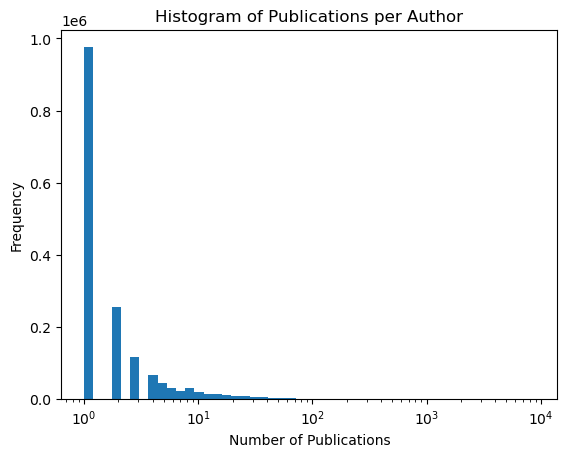


Publications per Author:
Mean: 3.46, Std: 12.77
Q1: 1.0, Median: 1.0, Q3: 3.0


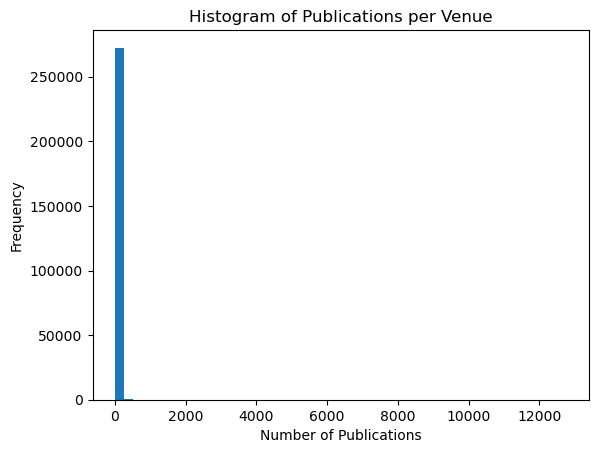


Publications per Venue:
Mean: 8.73, Std: 106.80
Q1: 1.0, Median: 1.0, Q3: 1.0
Venue with largest publications: IEEE Transactions on Information Theory with 12754 pubs


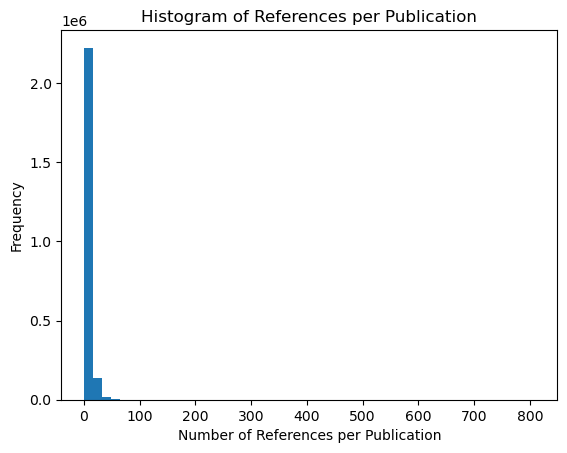

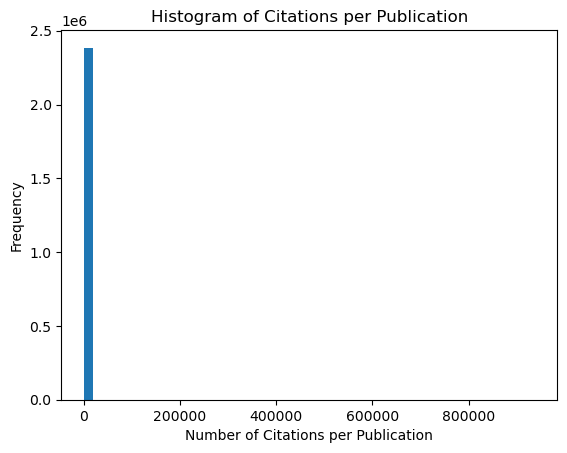

Publication with max references: 2015217 (809 references)
Publication with max citations: 2135000 (938039 citations)


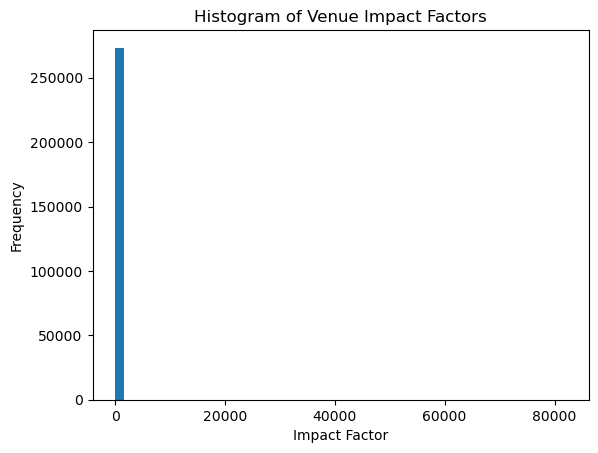

Venue with highest impact factor: Graphics Interface 1990 (82080.00)
NOTE: Consider whether outliers or low publication counts affect this number.


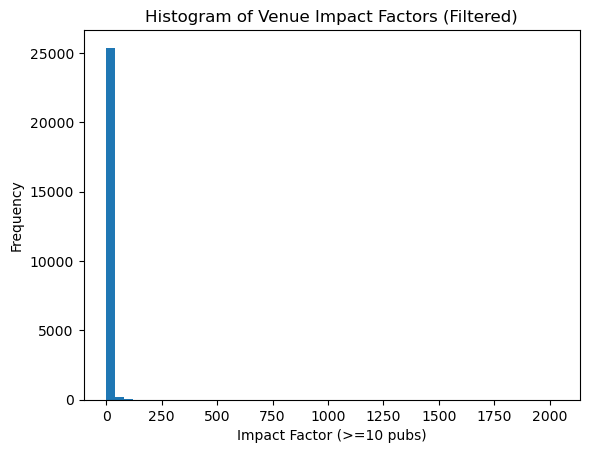

Filtered - Venue with highest impact factor: Proceedings of the 19th ACM SIGKDD international conference on Knowledge discovery and data mining (2033.20)
For venue Proceedings of the 19th ACM SIGKDD international conference on Knowledge discovery and data mining: Mean citations = 2033.20, Median citations = 1.00


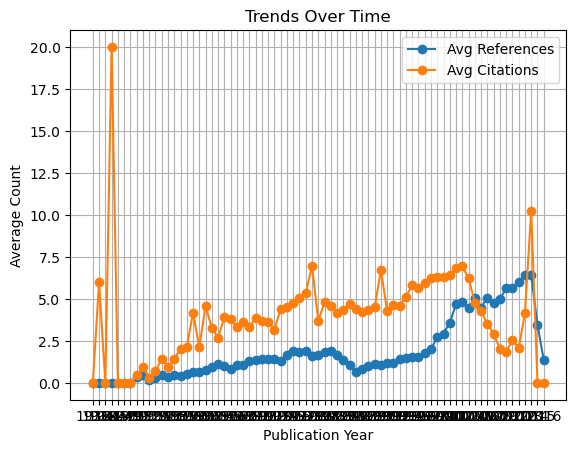

Trend analysis complete.


In [12]:
# Change the file path as appropriate for your Aminer dataset
file_path = "acm.txt"
if not os.path.exists(file_path):
    print("Dataset file not found:", file_path)
else:
    start = time.time()
    publications = parse_aminer_data(file_path)
    parse_time = time.time() - start
    print("Parsing time: {:.2f} seconds".format(parse_time))
    analyze_aminer(publications)

### Problem 2: Kosarak Association Rules

In [5]:
import time

def convert_itemset_to_arff(input_path, output_path):
    """
    Reads an itemset file where each line is a transaction (space-separated item IDs)
    and writes a sparse ARFF file.
    
    The ARFF file will have one binary attribute per distinct item.
    """
    transactions = []
    unique_items = set()
    print("Reading transactions...")
    with open(input_path, 'r') as fin:
        for line in fin:
            items = line.strip().split()
            if items:
                transactions.append(items)
                unique_items.update(items)
    unique_items = sorted(unique_items, key=lambda x: int(x))  # sort numerically if applicable
    item_index = {item: idx for idx, item in enumerate(unique_items)}
    n_items = len(unique_items)
    n_trans = len(transactions)
    print("Total transactions:", n_trans)
    print("Total unique items (attributes):", n_items)
    
    # Write ARFF header
    with open(output_path, 'w') as fout:
        fout.write("@RELATION kosarak\n\n")
        for item in unique_items:
            fout.write("@ATTRIBUTE item_{} {{0,1}}\n".format(item))
        fout.write("\n@DATA\n")
        # Write each transaction in sparse format: {index 1, ...}
        for trans in transactions:
            indices = sorted([item_index[item] for item in trans])
            entries = [f"{i} 1" for i in indices]
            fout.write("{" + ", ".join(entries) + "}\n")
    print("ARFF file written to:", output_path)


input_path = "kosarak.dat"  # adjust the path to your Kosarak file
output_path = "kosarak.arff"
start = time.time()
convert_itemset_to_arff(input_path, output_path)
conv_time = time.time() - start
print("Conversion took {:.2f} seconds.".format(conv_time))

Reading transactions...
Total transactions: 990002
Total unique items (attributes): 41270
ARFF file written to: kosarak.arff
Conversion took 3.38 seconds.


### Problem 3 MNIST, 20 NG Preprocessing

In [6]:
# For text processing (Problem 3: 20NG)
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

# For MNIST (Problem 3: MNIST)
from sklearn.datasets import fetch_openml
import numpy as np

def preprocess_mnist(normalization='minmax'):
    """
    Loads MNIST, normalizes the data, and computes pairwise similarity matrices.
    
    normalization: 'minmax' or 'zscore'
    """
    print("Fetching MNIST data...")
    mnist = fetch_openml('mnist_784', version=1)
    X = mnist.data.astype(np.float64)
    y = mnist.target.astype(np.int32)
    print("MNIST data shape:", X.shape)
    
    if normalization == 'minmax':
        # Shift-and-scale normalization to [0,1]
        X_norm = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0) + 1e-8)
    elif normalization == 'zscore':
        # Zero mean, unit variance
        X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)
    else:
        raise ValueError("Unknown normalization method")
    
    # Compute pairwise Euclidean distances (library version)
    print("Computing pairwise Euclidean distances (sample 1000 datapoints)...")
    sample = X_norm[:1000]
    dist_matrix = euclidean_distances(sample, sample)
    
    # Compute pairwise cosine similarity
    print("Computing pairwise Cosine similarities (sample 1000 datapoints)...")
    sim_matrix = cosine_similarity(sample, sample)
    
    print("MNIST preprocessing complete.")
    return X_norm, y, dist_matrix, sim_matrix


def preprocess_20ng():
    """
    Loads the 20 Newsgroups dataset, applies TF weighting, and computes pairwise cosine similarity.
    """
    print("Fetching 20 Newsgroups data...")
    data = fetch_20newsgroups(subset='all')
    texts = data.data
    labels = data.target
    print("Number of documents:", len(texts))
    
    # Use TfidfVectorizer for TF normalization (sparse output)
    vectorizer = TfidfVectorizer(stop_words='english', max_features=10000)
    X_tfidf = vectorizer.fit_transform(texts)
    print("TF-IDF matrix shape:", X_tfidf.shape)
    
    # Compute pairwise cosine similarity on a sample due to large size.
    print("Computing pairwise Cosine similarities (sample 500 documents)...")
    sample = X_tfidf[:500]
    sim_matrix = cosine_similarity(sample, sample)
    
    # Also compute Euclidean distances (using sparse routines if needed)
    print("Computing pairwise Euclidean distances (sample 500 documents)...")
    dist_matrix = euclidean_distances(sample.toarray(), sample.toarray())
    
    print("20 Newsgroups preprocessing complete.")
    return X_tfidf, labels, dist_matrix, sim_matrix


 # Preprocess MNIST
X_mnist, y_mnist, mnist_euc, mnist_cos = preprocess_mnist(normalization='minmax')

# Preprocess 20NG
X_20ng, labels_20ng, ng_euc, ng_cos = preprocess_20ng()

# Here you could save the matrices or pass them on to Problem 4.
print("Problem 3 execution complete.")



Fetching MNIST data...
MNIST data shape: (70000, 784)
Computing pairwise Euclidean distances (sample 1000 datapoints)...
Computing pairwise Cosine similarities (sample 1000 datapoints)...
MNIST preprocessing complete.
Fetching 20 Newsgroups data...
Number of documents: 18846
TF-IDF matrix shape: (18846, 10000)
Computing pairwise Cosine similarities (sample 500 documents)...
Computing pairwise Euclidean distances (sample 500 documents)...
20 Newsgroups preprocessing complete.
Problem 3 execution complete.


### PROBLEM 4: MNIST, 20 NG : Train and test KNN classification (supervised)

In [7]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.sparse import csr_matrix, issparse

class KNNClassifier:
    """
    A simple K-Nearest Neighbors classifier.
    """
    def __init__(self, k=5, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
        
    def fit(self, X, y):
        """
        Fit the KNN classifier.
        
        Parameters:
        -----------
        X : scipy.sparse.csr_matrix or numpy.ndarray
            Training data
        y : array-like
            Target values
        """
        # Ensure X is in a memory-efficient format
        if not issparse(X):
            X = csr_matrix(X)
        
        self.X_train = X
        self.y_train = np.array(y)
        
    def _compute_sparse_distances(self, x, X):
        """
        Compute distances for sparse matrices using scipy's efficient methods.
        
        Parameters:
        -----------
        x : scipy.sparse.csr_matrix
            Single sample to compute distances from
        X : scipy.sparse.csr_matrix
            Training samples
        
        Returns:
        --------
        numpy.ndarray
            Distances from x to all samples in X
        """
        if not issparse(x):
            x = csr_matrix(x)
        
        if self.distance_metric == 'euclidean':
            # Compute squared Euclidean distance efficiently
            # Squared Euclidean = ||x||^2 + ||X||^2 - 2 * x · X
            x_squared = x.power(2).sum()
            X_squared = X.power(2).sum(axis=1)
            cross_term = x.dot(X.T).toarray()[0]
            
            distances = np.sqrt(x_squared + X_squared.A1 - 2 * cross_term)
        
        elif self.distance_metric == 'manhattan':
            # Manhattan distance for sparse matrices
            distances = np.abs(X.toarray() - x.toarray()).sum(axis=1)
        
        else:
            raise ValueError("Unsupported distance metric")
        
        return distances
    
    def predict(self, X):
        """
        Predict class labels for samples in X.
        
        Parameters:
        -----------
        X : scipy.sparse.csr_matrix or numpy.ndarray
            Samples to predict labels for
        
        Returns:
        --------
        numpy.ndarray
            Predicted class labels
        """
        # Ensure X is in a memory-efficient format
        if not issparse(X):
            X = csr_matrix(X)
        
        preds = []
        for x in X:
            # Compute distances
            distances = self._compute_sparse_distances(x, self.X_train)
            
            # Get indices of k nearest neighbors
            nn_idx = np.argsort(distances)[:self.k]
            nn_labels = self.y_train[nn_idx]
            
            # Majority vote
            vote = Counter(nn_labels).most_common(1)[0][0]
            preds.append(vote)
        
        return np.array(preds)


In [8]:
def run_knn_on_mnist():
    # Load MNIST data using the preprocessing function.
    X, y, _, _ = preprocess_mnist(normalization='minmax')
    # For speed, use a subset.
    X_sub, _, y_sub, _ = train_test_split(X, y, train_size=0.2, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, test_size=0.5, random_state=42)
    
    print("Training KNN on MNIST subset:")
    knn = KNNClassifier(k=3, distance_metric='euclidean')
    knn.fit(X_train, y_train)
    preds_train = knn.predict(X_train)
    preds_test = knn.predict(X_test)
    
    train_acc = accuracy_score(y_train, preds_train)
    test_acc = accuracy_score(y_test, preds_test)
    print("Training accuracy: {:.2f}%".format(train_acc*100))
    print("Testing accuracy: {:.2f}%".format(test_acc*100))


def run_knn_on_20ng():
    # Load 20NG dataset
    X_sparse, labels, _, _ = preprocess_20ng()
    # Convert sparse matrix to dense for simplicity (only on a small subset)
    X_dense = X_sparse[:1000].toarray()
    labels = np.array(labels[:1000])
    X_train, X_test, y_train, y_test = train_test_split(X_dense, labels, test_size=0.5, random_state=42)
    
    print("Training KNN on 20 Newsgroups subset:")
    knn = KNNClassifier(k=3, distance_metric='euclidean')
    knn.fit(X_train, y_train)
    preds_train = knn.predict(X_train)
    preds_test = knn.predict(X_test)
    
    train_acc = accuracy_score(y_train, preds_train)
    test_acc = accuracy_score(y_test, preds_test)
    print("Training accuracy: {:.2f}%".format(train_acc*100))
    print("Testing accuracy: {:.2f}%".format(test_acc*100))

    

In [9]:
# Run on MNIST
run_knn_on_mnist()
# Run on 20 Newsgroups
run_knn_on_20ng()

Fetching MNIST data...
MNIST data shape: (70000, 784)
MNIST data shape: (70000, 784)
Computing pairwise Euclidean distances (sample 1000 datapoints)...
Computing pairwise Cosine similarities (sample 1000 datapoints)...
MNIST preprocessing complete.
Computing pairwise Euclidean distances (sample 1000 datapoints)...
Computing pairwise Cosine similarities (sample 1000 datapoints)...
MNIST preprocessing complete.
Training KNN on MNIST subset:
Training KNN on MNIST subset:


C:\Users\theja\AppData\Local\Temp\ipykernel_64480\75963063.py:58: RuntimeWarning: invalid value encountered in sqrt
  distances = np.sqrt(x_squared + X_squared.A1 - 2 * cross_term)


Training accuracy: 95.71%
Testing accuracy: 94.60%
Fetching 20 Newsgroups data...
Number of documents: 18846
TF-IDF matrix shape: (18846, 10000)
Computing pairwise Cosine similarities (sample 500 documents)...
Computing pairwise Euclidean distances (sample 500 documents)...
20 Newsgroups preprocessing complete.
Training KNN on 20 Newsgroups subset:
TF-IDF matrix shape: (18846, 10000)
Computing pairwise Cosine similarities (sample 500 documents)...
Computing pairwise Euclidean distances (sample 500 documents)...
20 Newsgroups preprocessing complete.
Training KNN on 20 Newsgroups subset:


C:\Users\theja\AppData\Local\Temp\ipykernel_64480\75963063.py:58: RuntimeWarning: invalid value encountered in sqrt
  distances = np.sqrt(x_squared + X_squared.A1 - 2 * cross_term)


Training accuracy: 86.20%
Testing accuracy: 49.00%
